<a href="https://colab.research.google.com/github/Raffy0-1/DHC-ML-Task_3/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

Importing Dataset directly from Kaggle

In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [36]:
# To know the name of csv file
import os

os.listdir("/kaggle/input/heart-disease-data")

['heart_disease_uci.csv']

Loading the dataset

In [37]:
df = pd.read_csv("/kaggle/input/heart-disease-data/heart_disease_uci.csv")

print(df.head())
print(df.shape)
print(df.columns)

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
(920, 16

Data Cleaning

In [38]:
# checking the missing Values
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [39]:
# dropping/removing the missing values
df.dropna(inplace=True)

In [40]:
#  Checking again
print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [41]:
# checking duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [42]:
# # if there were duplicate rows i would have removed them
# df.drop_duplicates(inplace=True)

Converting target to binary

In [43]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df.drop('num', axis=1, inplace=True)

Encoding Categorical colunms as our models require numeric data

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['sex','dataset','cp','fbs','restecg','exang','slope','thal']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [45]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


Now performing EDA

In [46]:
# Fetching dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        299 non-null    int64  
 1   age       299 non-null    int64  
 2   sex       299 non-null    int64  
 3   dataset   299 non-null    int64  
 4   cp        299 non-null    int64  
 5   trestbps  299 non-null    float64
 6   chol      299 non-null    float64
 7   fbs       299 non-null    int64  
 8   restecg   299 non-null    int64  
 9   thalch    299 non-null    float64
 10  exang     299 non-null    int64  
 11  oldpeak   299 non-null    float64
 12  slope     299 non-null    int64  
 13  ca        299 non-null    float64
 14  thal      299 non-null    int64  
 15  target    299 non-null    int64  
dtypes: float64(5), int64(11)
memory usage: 39.7 KB


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,299.000000,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,153.872910,54.521739,0.67893,0.010033,0.949833,131.715719,246.785953,0.143813,0.525084,149.327759,0.331104,1.058528,1.394649,0.672241,1.331104,0.464883
std,95.896287,9.030264,0.46767,0.129141,1.033414,17.747751,52.532582,0.351488,0.526358,23.121062,0.471399,1.162769,0.616962,0.937438,0.585681,0.499601
min,1.000000,29.000000,0.00000,0.000000,0.000000,94.000000,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.500000,48.000000,0.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.500000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,151.000000,56.000000,1.00000,0.000000,1.000000,130.000000,242.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,227.500000,61.000000,1.00000,0.000000,2.000000,140.000000,275.500000,0.000000,1.000000,165.500000,1.000000,1.600000,2.000000,1.000000,2.000000,1.000000
max,749.000000,77.000000,1.00000,2.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


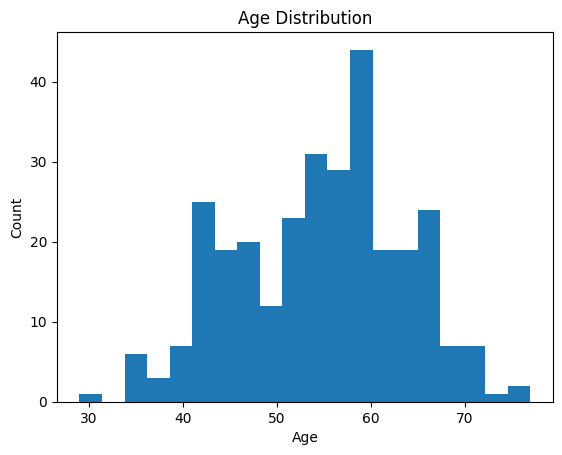

In [47]:
# Distribution of age
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [48]:
print('Age Distribution Statistics:')
print(df['age'].describe())

Age Distribution Statistics:
count    299.000000
mean      54.521739
std        9.030264
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64


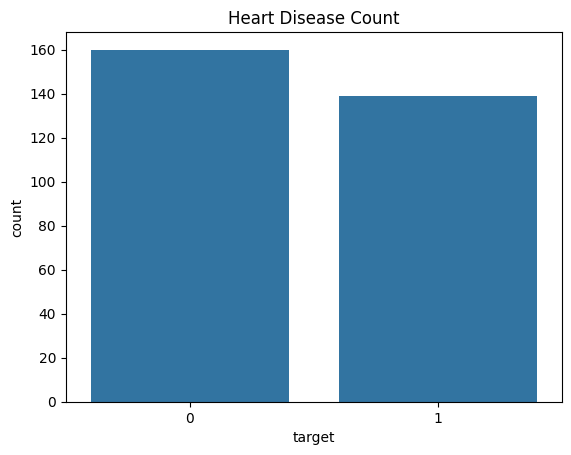

In [49]:
# Heart Disease count
sns.countplot(x='target', data=df)
plt.title("Heart Disease Count")
plt.show()

In [50]:
print('Heart Disease Count (0: No Disease, 1: Disease):')
print(df['target'].value_counts())

Heart Disease Count (0: No Disease, 1: Disease):
target
0    160
1    139
Name: count, dtype: int64


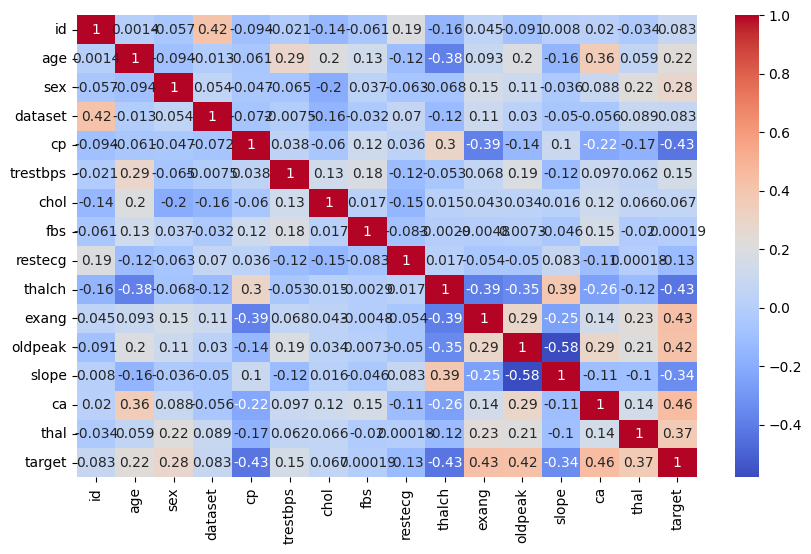

In [51]:
# Correlation to show which feature affecting most
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [52]:
print('Correlation Matrix:')
print(df.corr())

Correlation Matrix:
                id       age       sex   dataset        cp  trestbps  \
id        1.000000  0.001379 -0.056881  0.418747 -0.094403 -0.021051   
age       0.001379  1.000000 -0.093693 -0.013136 -0.060833  0.286149   
sex      -0.056881 -0.093693  1.000000  0.053518 -0.047326 -0.065209   
dataset   0.418747 -0.013136  0.053518  1.000000 -0.071649 -0.007536   
cp       -0.094403 -0.060833 -0.047326 -0.071649  1.000000  0.038374   
trestbps -0.021051  0.286149 -0.065209 -0.007536  0.038374  1.000000   
chol     -0.138639  0.199258 -0.202500 -0.155494 -0.060095  0.134240   
fbs      -0.060584  0.132752  0.036869 -0.031895  0.121552  0.179791   
restecg   0.192594 -0.115722 -0.062598  0.070336  0.036252 -0.120111   
thalch   -0.159716 -0.384176 -0.067820 -0.123605  0.301240 -0.053320   
exang     0.045102  0.092506  0.148956  0.110614 -0.385983  0.067843   
oldpeak  -0.091294  0.195929  0.108107  0.029597 -0.140811  0.191144   
slope     0.007997 -0.157545 -0.036213 -0.04

Preparing features and target

In [53]:
X = df.drop('target', axis=1)
y = df['target']

Train Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training the model

In [55]:
# Logistic Regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

Prediction

In [56]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0
 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0 0]


In [57]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8833333333333333


Confusion Matrix

<Axes: >

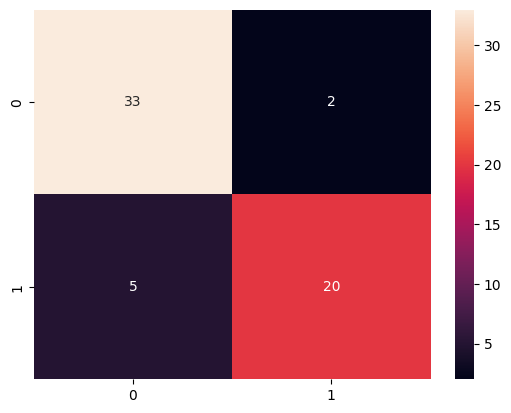

In [58]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")

33 were correctly identified as negative (no disease).
20 were correctly identified as positive (disease).
2 individuals without disease were wrongly classified as having disease.
5 individuals with disease were wrongly classified as not having disease.

ROC Curve

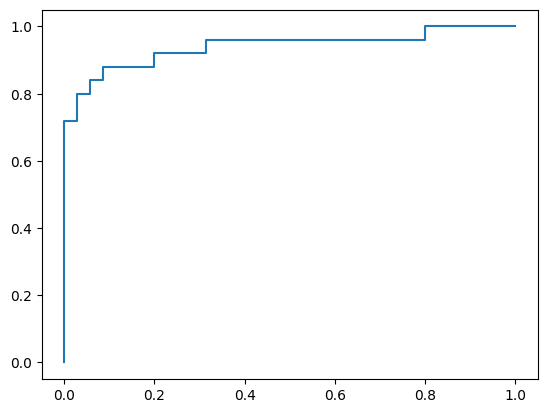

In [59]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

In [60]:
# ROC-AUC score
roc_auc_score(y_test, y_prob)

np.float64(0.9394285714285714)

Feature importance

In [61]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

importance = tree.feature_importances_

[0.07627655 0.05897018 0.03870516 0.         0.26379938 0.03602044
 0.09049042 0.01928772 0.01621287 0.07323743 0.06574596 0.06317113
 0.06961262 0.09368066 0.03478949]


In [62]:
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print('Feature Importance:')
print(feature_importance_df)

Feature Importance:
     feature  importance
4         cp    0.263799
13        ca    0.093681
6       chol    0.090490
0         id    0.076277
9     thalch    0.073237
12     slope    0.069613
10     exang    0.065746
11   oldpeak    0.063171
1        age    0.058970
2        sex    0.038705
5   trestbps    0.036020
14      thal    0.034789
7        fbs    0.019288
8    restecg    0.016213
3    dataset    0.000000


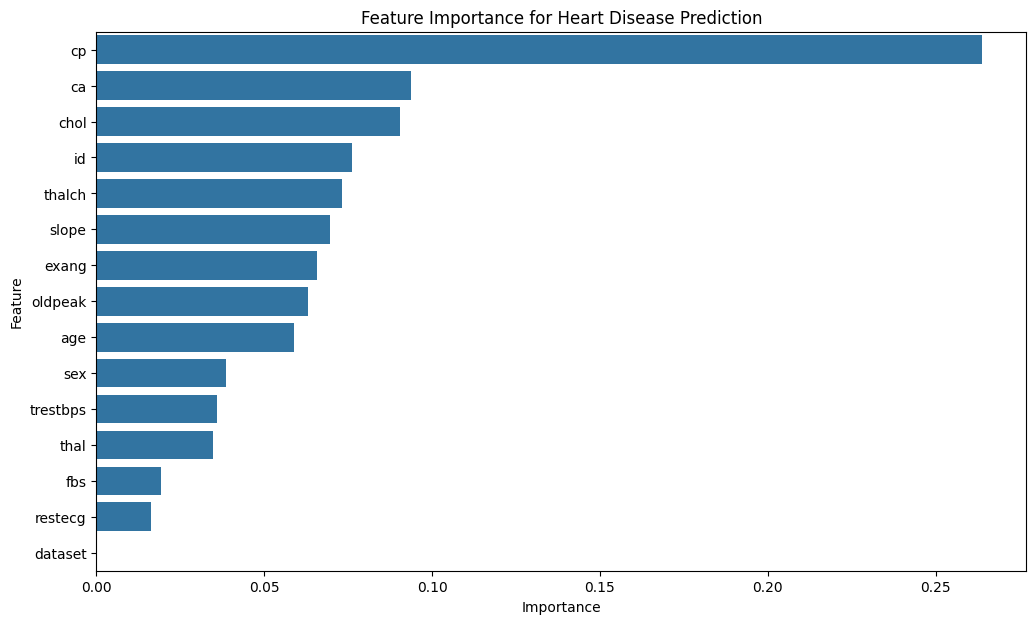

In [63]:
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance for Heart Disease Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()